In [1]:
from pandas import concat, read_csv

REGIONS = ('DE', 'DR', 'V')
CSV_COLUMNS = ('I', 'R', 'E', 'A', 'DE', 'DA', 'H', 'M')
NUMERIC_COLUMNS = ('DA', 'H', 'M')
converters = {
    col: lambda value: value.replace(',', '')
    for col in NUMERIC_COLUMNS
}
df = concat(
    (
        read_csv(
            f'R/{region}.csv',
            index_col='I',
            usecols=CSV_COLUMNS,
            converters=converters,
            na_filter=False
        )
        for region in REGIONS
    ),
    keys=REGIONS,
    names=('RE',)
)
df

R   E  A  DE    DA      H      M
RE I                                    
DE 1    T   0  0   8  2947   1425   4611
   1    D   1  0   3  1818      0    650
   1    D   2  0   7  4735    487    308
   1    S   1  0   3  2078   2748      0
   1    S   1  1   3   269   5848    189
...    ..  .. ..  ..   ...    ...    ...
V  491  T  12  1   9  7745     12  12986
   491  D   6  0  10  7838   1433      0
   491  D  12  2   8  8688      0    472
   491  S   2  8   7  1041  11310    256
   491  S   2  7   8  3005   8648    548

[9510 rows x 7 columns]

In [2]:
from string import digits

digit_dict = {'': 0, 'T': 1, 'D': 2, 'S': 3}
for i, d in enumerate(digits, 1):
    digit_dict[d] = i
digit_dict

{'': 0,
 'T': 1,
 'D': 2,
 'S': 3,
 '0': 1,
 '1': 2,
 '2': 3,
 '3': 4,
 '4': 5,
 '5': 6,
 '6': 7,
 '7': 8,
 '8': 9,
 '9': 10}

In [3]:
from pandas import DataFrame
from numpy import uint8

result = {}
for col_name, max_len in df.map(len).max().items():
    for i in range(-max_len, 0):
        result[f'{col_name}{-i}'] = df[col_name].str[i].map(digit_dict).fillna(0).astype(uint8)
result_df = DataFrame(result)
result_df

R1  E2  E1  A2  A1  DE2  DE1  DA5  DA4  DA3  ...  H5  H4  H3  H2  H1  \
RE I                                                 ...                       
DE 1     1   0   1   0   1    0    9    0    3   10  ...   0   2   5   3   6   
   1     2   0   2   0   1    0    4    0    2    9  ...   0   0   0   0   1   
   1     2   0   3   0   1    0    8    0    5    8  ...   0   0   5   9   8   
   1     3   0   2   0   1    0    4    0    3    1  ...   0   3   8   5   9   
   1     3   0   2   0   2    0    4    0    0    3  ...   0   6   9   5   9   
...     ..  ..  ..  ..  ..  ...  ...  ...  ...  ...  ...  ..  ..  ..  ..  ..   
V  491   1   2   3   0   2    0   10    0    8    8  ...   0   0   0   2   3   
   491   2   0   7   0   1    2    1    0    8    9  ...   0   2   5   4   4   
   491   2   2   3   0   3    0    9    0    9    7  ...   0   0   0   0   1   
   491   3   0   3   0   9    0    8    0    2    1  ...   2   2   4   2   1   
   491   3   0   3   0   8    0    9    0    4    1  ...   0   9   7   5   9   

        M5  M4  M3  M2  M1  
RE I                        
DE 1     0   5   7   2   2  
   1     0   0   7   6   1  
   1     0   0   4   1   9  
   1     0   0   0   0   1  
   1     0   0   2   9  10  
...     ..  ..  ..  ..  ..  
V  491   2   3  10   9   7  
   491   0   0   0   0   1  
   491   0   0   5   8   3  
   491   0   0   3   6   7  
   491   0   0   6   5   9  

[9510 rows x 22 columns]

In [28]:
result_df['E1'].value_counts()

E1
1     1032
2     1008
3      983
5      959
6      955
4      949
7      933
8      927
10     856
9      841
0       67
Name: count, dtype: int64

In [4]:
df_numpy = result_df.to_numpy().reshape(-1, 10, 22)
df_0, df_1 = df_numpy[:, :, 0], df_numpy[:, :, 1:]
df_0.shape, df_1.shape

((951, 10), (951, 10, 21))

In [5]:
from pathlib import Path
from tensorflow.random import shuffle
import tensorflow as tf
from tensorflow import gather

image_paths = sorted(map(str, Path().rglob("*.png")))
data_count = len(image_paths)
indices = shuffle(tf.range(data_count))
X_shuffled = gather(image_paths, indices)
y_shuffled_0 = gather(df_0, indices)
y_shuffled_1 = gather(df_1, indices)

train_size = int(data_count * .9)
train_X, val_X = X_shuffled[:train_size], X_shuffled[train_size:]
train_y_0, val_y_0 = y_shuffled_0[:train_size], y_shuffled_0[train_size:]
train_y_1, val_y_1 = y_shuffled_1[:train_size], y_shuffled_1[train_size:]
train_X.shape, train_y_0.shape, train_y_1.shape

2026-03-07 14:36:41.528286: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.11/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr

(TensorShape([819]), TensorShape([819, 10]), TensorShape([819, 10, 21]))

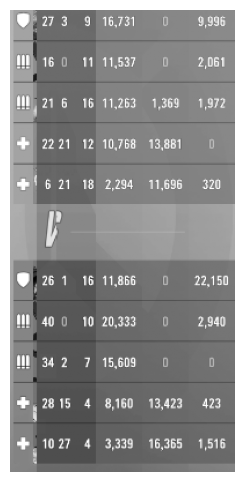

tf.Tensor(
[[ 1  3  8  0  4  0 10  2  7  8  4  2  0  0  0  0  1  0 10 10 10  7]
 [ 2  2  7  0  1  2  2  2  2  6  4  8  0  0  0  0  1  0  3  1  7  2]
 [ 2  3  2  0  7  2  7  2  2  3  7  4  0  2  4  7 10  0  2 10  8  3]
 [ 3  3  3  3  2  2  3  2  1  8  7  9  2  4  9  9  2  0  0  0  0  1]
 [ 3  0  7  3  2  2  9  0  3  3 10  5  2  2  7 10  7  0  0  4  3  1]
 [ 1  3  7  0  2  2  7  2  2  9  7  7  0  0  0  0  1  3  3  2  6  1]
 [ 2  5  1  0  1  2  1  3  1  4  4  4  0  0  0  0  1  0  3 10  5  1]
 [ 2  4  5  0  3  0  8  2  6  7  1 10  0  0  0  0  1  0  0  0  0  1]
 [ 3  3  9  2  6  0  5  0  9  2  7  1  2  4  5  3  4  0  0  5  3  4]
 [ 3  2  1  3  8  0  5  0  4  4  4 10  2  7  4  7  6  0  2  6  2  7]], shape=(10, 22), dtype=uint8)


In [19]:
from tensorflow.data import Dataset, AUTOTUNE
from tensorflow.image import decode_png, resize
from tensorflow.io import read_file
from matplotlib.pyplot import figure, axis, imshow, show
from numpy import array


def preprocess_image(path, label):
    image = decode_png(read_file(path), channels=1)[230:930, 530:1370]
    hud_parts = [
        image[:, :40], image[:, 390:420], image[:, 450:480],
        image[:, 500:530], image[:, 570:640], image[:, 670:740], image[:, 770:]
    ]
    cropped = tf.concat(hud_parts, axis=1)
    resized = resize(cropped, (400, 194)) / 255
    return resized, label


def make_dataset(X, y, shuffle=False, batch_size=32):
    ds = Dataset.from_tensor_slices((X, y))
    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_X, {"output_1": train_y_0, "output_2": train_y_1}, shuffle=False)
val_ds = make_dataset(val_X, {"output_1": val_y_0, "output_2": val_y_1}, shuffle=False)
for x_batch, y_batch in train_ds.take(1):
    figure(figsize=(6, 6))
    axis("off")
    imshow(x_batch[0], cmap='gray')
    show()
    y_expanded = tf.expand_dims(y_batch["output_1"], axis=-1)   # (32, 10, 1)
    y_result = tf.concat([y_expanded, y_batch["output_2"]], axis=-1)
    print(y_result[0])

In [35]:
import tensorflow as tf
from tensorflow.keras import layers, models


def build_model():
    inputs = layers.Input(shape=(400, 194, 1))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    # feature map shape roughly
    # (50, 24, 128)
    # width 방향을 sequence로 사용
    x = layers.Permute((2, 1, 3))(x)
    x = layers.Reshape((24, 50 * 128))(x)
    # sequence modeling
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(256))(x)
    shared = layers.Dense(512, activation="relu")(x)
    # output1
    out1 = layers.Dense(10 * 4)(shared)
    out1 = layers.Reshape((10, 4), name="output_1")(out1)
    # output2
    out2 = layers.Dense(10 * 21 * 11)(shared)
    out2 = layers.Reshape((10, 21, 11), name="output_2")(out2)
    return models.Model(inputs, [out1, out2])


model = build_model()
model.compile(
    optimizer="adam",
    loss={
        "output_1": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        "output_2": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    },
    metrics={
        "output_1": "sparse_categorical_accuracy",
        "output_2": "sparse_categorical_accuracy",
    }
)
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 400, 194,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 400, 194,  │        320 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 200, 97,   │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 200, 97,   │     18,496 │ max_pooling2d_18… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_19    │ (None, 100, 48,   │          0 │ conv2d_21[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 100, 48,   │     73,856 │ max_pooling2d_19… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 50, 24,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_1 (Permute) │ (None, 24, 50,    │          0 │ max_pooling2d_20… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 24, 6400)  │          0 │ permute_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 24, 512)   │ 13,633,536 │ reshape_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 512)       │  1,574,912 │ bidirectional_2[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 512)       │    262,656 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 40)        │     20,520 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 2310)      │  1,185,030 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_1 (Reshape)  │ (None, 10, 4)     │          0 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_2 (Reshape)  │ (None, 10, 21,    │          0 │ dense_17[0][0]    │
│                     │ 11)               │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,769,326 (63.97 MB)

 Trainable params: 16,769,326 (63.97 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
from tensorflow.keras.callbacks import EarlyStopping

history = model.fit(
    train_ds,
    epochs=256,
    callbacks=EarlyStopping(patience=16, verbose=1, restore_best_weights=True),
    validation_data=val_ds
)

Epoch 1/256
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 226ms/step - loss: 2.1412 - output_1_loss: 0.3560 - output_1_sparse_categorical_accuracy: 0.9082 - output_2_loss: 1.7847 - output_2_sparse_categorical_accuracy: 0.3797 - val_loss: 1.8184 - val_output_1_loss: 0.2031 - val_output_1_sparse_categorical_accuracy: 0.9565 - val_output_2_loss: 1.6152 - val_output_2_sparse_categorical_accuracy: 0.4244
Epoch 2/256
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 188ms/step - loss: 1.8748 - output_1_loss: 0.2537 - output_1_sparse_categorical_accuracy: 0.9413 - output_2_loss: 1.6241 - output_2_sparse_categorical_accuracy: 0.4195 - val_loss: 1.8007 - val_output_1_loss: 0.2027 - val_output_1_sparse_categorical_accuracy: 0.9565 - val_output_2_loss: 1.5978 - val_output_2_sparse_categorical_accuracy: 0.4278
Epoch 3/256
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step - loss: 1.8618 - output_1_loss: 0.2520 - output_1_sparse_categorical_accuracy: 0.9413 - output_2_loss: 1.6127 - output_2_sparse_categorical_accuracy: 0.4192 - val_loss: 1.7

- 구체적인 숫자의 픽셀 크기를 제안해서 질문해 보자.
- 그래도 성능이 안 좋으면 Transformer 고려.

In [59]:
from numpy import unique, insert

losses = []
for y in tuple_data:
    counts = unique(y, return_counts=True)[1][1:]
    r = 1 / counts
    alpha = insert(r / sum(r) * len(counts), 0, 0)
    losses.append(SparseCategoricalFocalCrossentropy(alpha, from_logits=True))
    print(alpha)
len(losses)

[0.         0.99502378 1.00497622]
[0.         1.50020733 0.74968901 0.75010366]
[0.         0.01341114 0.02432201 0.0968016  0.46539233 4.40007292]
[0.         0.90752362 0.93676814 0.96900103 0.99797448 0.97318678
 0.99247902 1.00464989 1.01597627 1.11669263 1.08574814]
[0.00000000e+00 1.51482221e-03 4.58508490e-03 1.85155658e-02
 1.61496879e-01 2.90694382e+00 2.90694382e+00]
[0.         0.36664823 0.57538644 0.67346964 0.73366057 0.93047379
 1.00653432 1.15436905 1.37322712 1.46007152 1.72615932]
[0.         0.02402746 1.97597254]
[0.         1.14230743 1.08658511 1.11235929 1.00677943 0.95600836
 0.81295602 0.86003841 0.8769683  0.96742649 1.17857116]
[0.         0.05640314 1.94359686]
[0.         1.59512328 0.83892895 0.74263315 0.70385335 0.78289207
 0.87809718 0.92215223 1.06692283 1.23469848 1.23469848]
[0.         0.99010431 0.98357615 0.98249648 0.99671971 1.0011793
 1.01710715 0.96867348 1.01136079 1.0419724  1.00681023]
[0.         0.98900154 1.00111626 0.98574825 0.9771765

23